In [1]:
# Step 1: Import required libraries
import pandas as pd
from google.colab import files

# Step 2: Upload a file manually
uploaded = files.upload()  # This will open a file picker popup

# Step 3: Get the filename (works even if multiple files are uploaded)
filename = list(uploaded.keys())[0]
print(f"Uploaded file: {filename}")

# Step 4: Load the file into a pandas DataFrame (assuming it's a CSV)
df = pd.read_csv(filename)

# Step 5: Display first few rows to confirm
print("✅ File loaded successfully!")
df.head()


Saving final_processed_pipeline (1).csv to final_processed_pipeline (1).csv
Uploaded file: final_processed_pipeline (1).csv
✅ File loaded successfully!


,DC,temp,DMC,RH,ISI,area
0,0.607908,0.354497,0.000000,0.327273,0.159664,0.0
1,0.653316,0.174603,0.048368,0.327273,0.159664,0.0
2,0.145918,0.576720,0.290793,0.254545,0.831933,0.0
3,0.165306,0.677249,0.311772,0.218182,0.310924,0.0
4,0.667857,0.095238,0.548368,0.872727,0.184874,0.0


In [32]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

import joblib

plt.rcParams['figure.figsize'] = (8,5)
sns.set_theme()


Available Columns: ['DC', 'temp', 'DMC', 'RH', 'ISI', 'area']

Numeric Columns: ['DC', 'temp', 'DMC', 'RH', 'ISI', 'area']


,count,mean,std,min,25%,50%,75%,max
DC,220.0,0.606320,0.223467,0.0,0.493367,0.652296,0.759694,1.00
temp,220.0,0.490308,0.195423,0.0,0.353175,0.481481,0.619048,1.00
DMC,220.0,0.480160,0.203305,0.0,0.358392,0.460373,0.598048,1.00
RH,220.0,0.473471,0.215364,0.0,0.327273,0.454545,0.600000,1.00
ISI,220.0,0.376547,0.226324,0.0,0.193277,0.336134,0.487395,1.00
area,220.0,1.220864,1.920072,0.0,0.000000,0.000000,1.787500,7.21


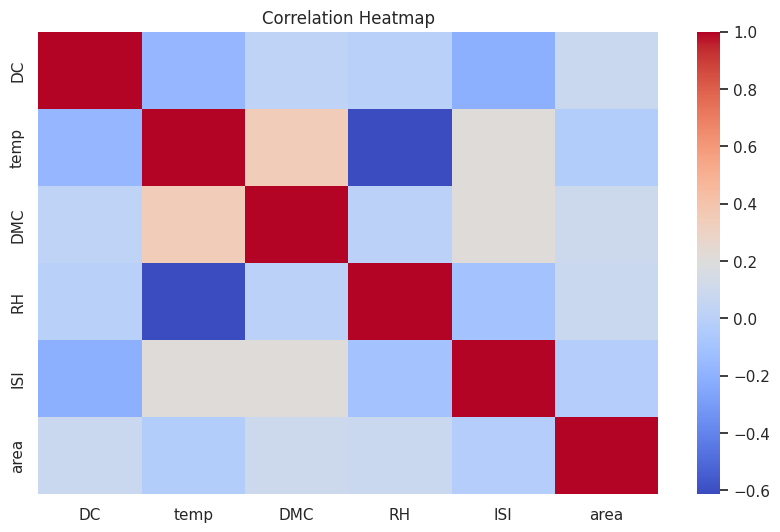

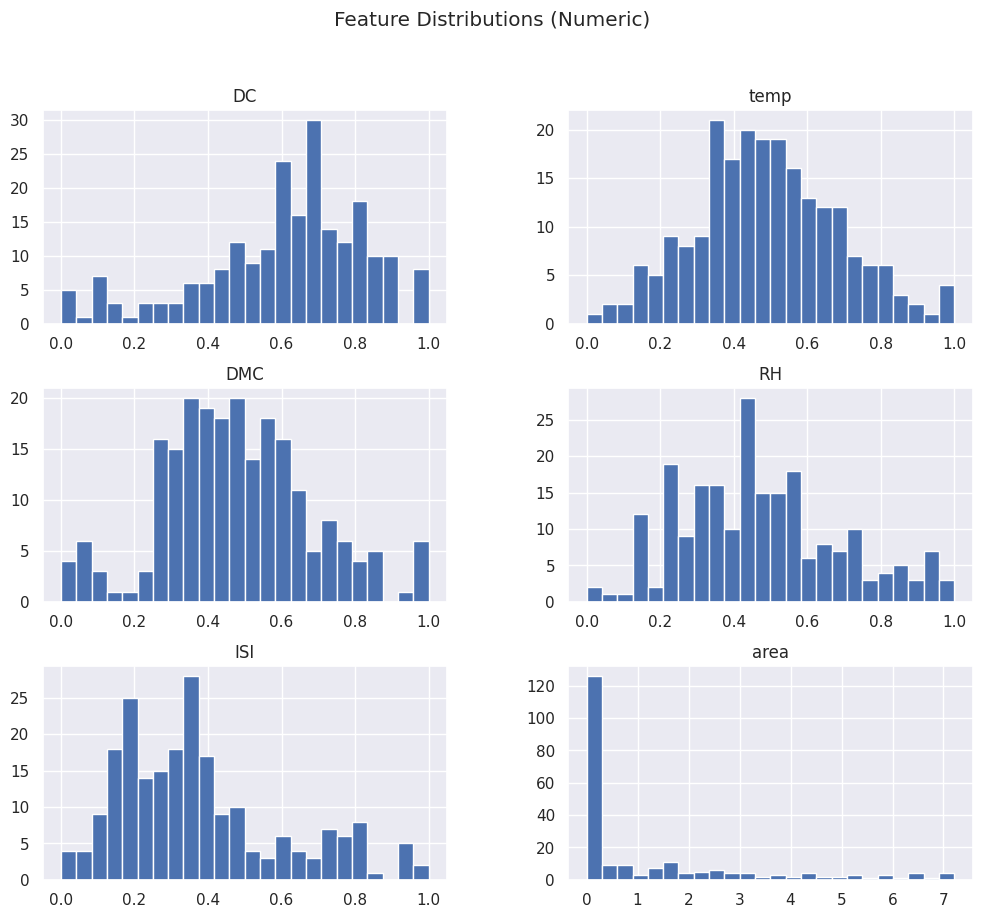

In [3]:
# display the columns of the dataset,lists numeric columns,and shows summary of statics
# Quick column inspection
print("Available Columns:", df.columns.tolist())

# Numeric summary
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric Columns:", numeric_cols)
display(df[numeric_cols].describe().T)

# Correlation heatmap
if len(numeric_cols) > 1:
    plt.figure(figsize=(10,6))
    sns.heatmap(df[numeric_cols].corr(), annot=False, cmap='coolwarm')
    plt.title("Correlation Heatmap")
    plt.show()

# Feature histograms
df[numeric_cols].hist(bins=24, figsize=(12,10))
plt.suptitle("Feature Distributions (Numeric)")
plt.show()


In [24]:
#this can identifies which columns are numeric and which are categorical
TARGET_COL = 'area'
CATEGORICAL_COLS = [] # Removed 'month' and 'day' as they are not in the dataframe

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]
categorical_features = list(set(categorical_features + CATEGORICAL_COLS))

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Apply preprocessing to the training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

Numeric Features: ['DC', 'temp', 'DMC', 'RH', 'ISI']
Categorical Features: []


In [11]:
#this cell splits the dataset into training and testing sets
TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

scaler = StandardScaler(with_mean=False)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Train shape: (176, 5) | Test shape: (44, 5)


In [12]:

#this defines a function takes model and test data
#calculate performance matrics-R2 score,MAE and RMSE to evaluate prediction accuracy
def evaluate_model(model, X_test, y_test, title_prefix=""):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    print(f"R²:   {r2:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")

    # Scatter plot of actual vs predicted
    plt.figure(figsize=(6,6))
    sns.scatterplot(x=y_test, y=preds)
    plt.xlabel("Actual area")
    plt.ylabel("Predicted area")
    plt.title(f"{title_prefix} — Actual vs Predicted")
    plt.show()

    return {"model": title_prefix, "R2": r2, "MAE": mae, "RMSE": rmse}


In [13]:
from sklearn.linear_model import LinearRegression

In [19]:
# Step 1: Apply preprocessing and scaling using a pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('scaler', scaler),
                           ('regressor', LinearRegression())])

# Step 2: Build and train model using the pipeline
pipeline.fit(X_train, y_train)

# Step 3: Make predictions using the pipeline
y_pred_lr = pipeline.predict(X_test)

In [22]:
# Step 3: Evaluate basic model
r2 = r2_score(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression Results (Before Tuning):")
print(f"R² = {r2:.4f}, MAE = {mae:.4f}, RMSE = {rmse:.4f}")

Linear Regression Results (Before Tuning):
R² = -0.1583, MAE = 1.7082, RMSE = 2.2496


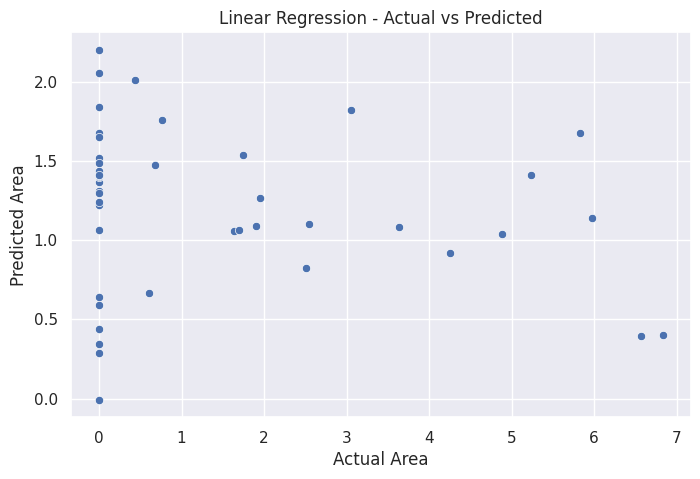

In [21]:
#plots actual and predicted values to visualize how close out model's prediction to real data
# Step 4: Visualize results
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(x=y_test, y=y_pred_lr)
plt.xlabel("Actual Area")
plt.ylabel("Predicted Area")
plt.title("Linear Regression - Actual vs Predicted")
plt.show()

In [25]:
# Step 5: Hyperparameter Tuning using GridSearchCV(automatically test different parameters combinations to find best version)
from sklearn.model_selection import GridSearchCV

# Define a pipeline that first preprocesses and then scales
pipeline_tuned = Pipeline(steps=[('preprocessor', preprocessor),
                                  ('scaler', scaler),
                                  ('regressor', LinearRegression())])

#define parameter grid - it will test different setting for intercept and whether coefficients should only be positive
param_grid_lr = {
    'regressor__fit_intercept': [True, False],
    'regressor__positive': [True, False]
}
# five fold cross validation
grid_lr = GridSearchCV(pipeline_tuned, param_grid=param_grid_lr,
                       cv=5, scoring='r2', n_jobs=-1)
grid_lr.fit(X_train, y_train) # Fit the pipeline on original training data

print("Best Params:", grid_lr.best_params_)
best_lr = grid_lr.best_estimator_

# Step 6: Evaluate tuned model
y_pred_tuned = best_lr.predict(X_test) # Predict using the pipeline on original test data
r2_tuned = r2_score(y_test, y_pred_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print(f"Linear Regression Results (After Tuning):")
print(f"R² = {r2_tuned:.4f}, MAE = {mae_tuned:.4f}, RMSE = {rmse_tuned:.4f}")

Best Params: {'regressor__fit_intercept': False, 'regressor__positive': True}
Linear Regression Results (After Tuning):
R² = -0.1271, MAE = 1.7072, RMSE = 2.2191


In [26]:
# --- Tuning Experiment 1 ---
#setup parameters i want to test for linear regression
param_grid_1 = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}
#test all combinations automatically
grid_1 = GridSearchCV(LinearRegression(), param_grid_1, cv=5, scoring='r2', n_jobs=-1)
grid_1.fit(X_train_processed, y_train)

print("Grid 1 Best Params:", grid_1.best_params_)
print("Grid 1 Best R²:", grid_1.best_score_)

Grid 1 Best Params: {'fit_intercept': False, 'positive': True}
Grid 1 Best R²: -0.08999961975402877


In [27]:
# --- Tuning Experiment 2 ---
# defining another parameter grids
param_grid_2 = {
    'copy_X': [True, False],
    'n_jobs': [-1, 1]
}

grid_2 = GridSearchCV(LinearRegression(), param_grid_2, cv=5, scoring='r2', n_jobs=-1)
grid_2.fit(X_train_processed, y_train)

print("Grid 2 Best Params:", grid_2.best_params_)
print("Grid 2 Best R²:", grid_2.best_score_)

Grid 2 Best Params: {'copy_X': True, 'n_jobs': -1}
Grid 2 Best R²: -0.10753299641795062


In [28]:
# --- Tuning Experiment 3 (Scaled Data) ---
#scaling ensure that all features are are on similar range.it helps this model train more effectively
X_train_scaled = preprocessor.fit_transform(X_train)
X_train_scaled = scaler.fit_transform(X_train_scaled)
grid_3 = GridSearchCV(LinearRegression(), param_grid_1, cv=10, scoring='r2', n_jobs=-1)
grid_3.fit(X_train_scaled, y_train)
print("Grid 3 (Scaled) Best Params:", grid_3.best_params_)
print("Grid 3 (Scaled) Best R²:", grid_3.best_score_)

Grid 3 (Scaled) Best Params: {'fit_intercept': False, 'positive': True}
Grid 3 (Scaled) Best R²: -0.15500967832102194


In [29]:
#summarizing and displaying the tuning experiment results
import pandas as pd

experiments = pd.DataFrame({
    "Experiment": ["Grid 1", "Grid 2", "Grid 3 (Scaled)"],
    "Best Params": [grid_1.best_params_, grid_2.best_params_, grid_3.best_params_],
    "Best R²": [grid_1.best_score_, grid_2.best_score_, grid_3.best_score_]
})

display(experiments)

,Experiment,Best Params,Best R²
0,Grid 1,"{'fit_intercept': False, 'positive': True}",-0.090000
1,Grid 2,"{'copy_X': True, 'n_jobs': -1}",-0.107533
2,Grid 3 (Scaled),"{'fit_intercept': False, 'positive': True}",-0.155010


In [30]:
#final evaluation step — testing the best Linear Regression model
best_lr = grid_3.best_estimator_   # or whichever grid performed best
X_test_scaled = preprocessor.transform(X_test)
X_test_scaled = scaler.transform(X_test_scaled)
y_pred_best = best_lr.predict(X_test_scaled)
r2_best = r2_score(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

print("🏆 Final Tuned Linear Regression Results:")
print(f"R² = {r2_best:.4f}, MAE = {mae_best:.4f}, RMSE = {rmse_best:.4f}")

🏆 Final Tuned Linear Regression Results:
R² = -0.1271, MAE = 1.7072, RMSE = 2.2191


,Model,R2,MAE,RMSE
0,Base Linear Regression,-0.158330,1.708241,2.249617
1,Tuned Grid 1,-0.127098,1.707195,2.219081
2,Tuned Grid 2 (Scaled),-0.127098,1.707195,2.219081


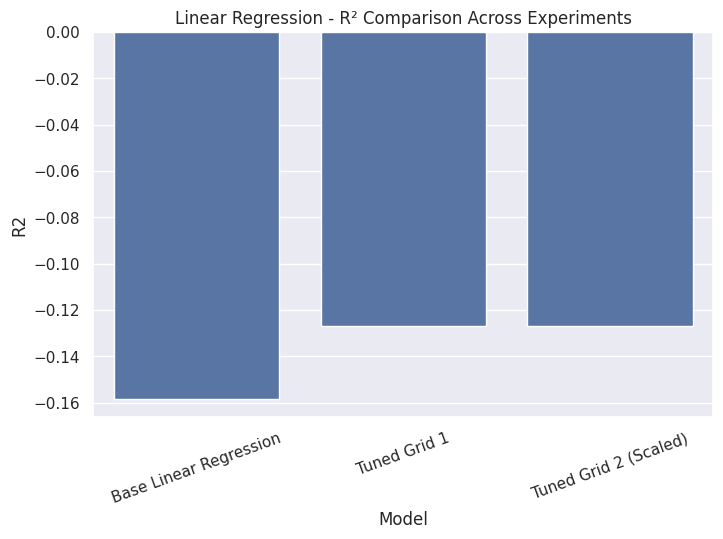

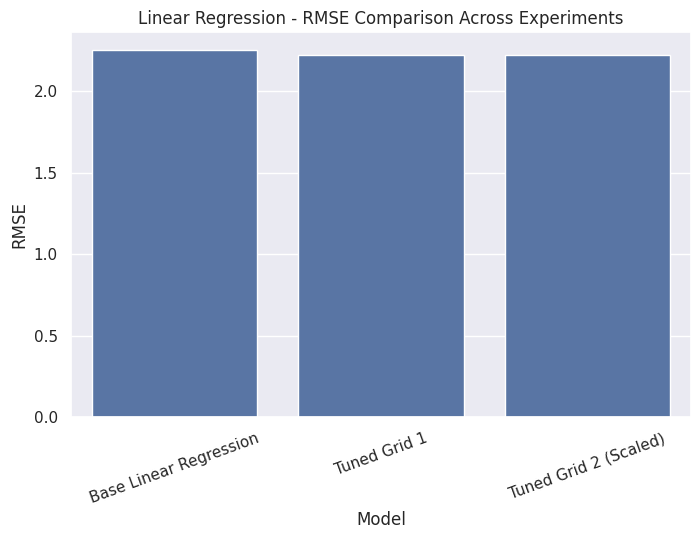

In [31]:
#complete Linear Regression experiment pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV


results = []

# Ensure preprocessor and scaler are defined if not already
if 'preprocessor' not in locals():
    # Assuming TARGET_COL and CATEGORICAL_COLS are defined
    numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = [c for c in X.columns if c not in numeric_features]
    categorical_features = list(set(categorical_features + CATEGORICAL_COLS))

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ]
    )

if 'scaler' not in locals():
    scaler = StandardScaler(with_mean=False)


# Apply preprocessing to the training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


# ---- Experiment 1: Base Model ----
lr_base = LinearRegression()
lr_base.fit(X_train_processed, y_train) # Fit on processed data
y_pred_base = lr_base.predict(X_test_processed) # Predict on processed data
results.append({
    "Model": "Base Linear Regression",
    "R2": r2_score(y_test, y_pred_base),
    "MAE": mean_absolute_error(y_test, y_pred_base),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_base))
})

# ---- Experiment 2: Tuned (Grid 1) ----
param_grid_1 = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}
grid_1 = GridSearchCV(LinearRegression(), param_grid=param_grid_1, cv=5, scoring='r2', n_jobs=-1)
grid_1.fit(X_train_processed, y_train) # Fit on processed data
best_lr1 = grid_1.best_estimator_
y_pred_grid1 = best_lr1.predict(X_test_processed) # Predict on processed data
results.append({
    "Model": "Tuned Grid 1",
    "R2": r2_score(y_test, y_pred_grid1),
    "MAE": mean_absolute_error(y_test, y_pred_grid1),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_grid1))
})

# ---- Experiment 3: Tuned (Grid 2 + Scaled using Pipeline) ----
# Define a pipeline that first preprocesses and then scales
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('scaler', scaler),
                           ('regressor', LinearRegression())])

param_grid_2 = {
    'regressor__fit_intercept': [True, False],
    'regressor__positive': [True, False],
    'regressor__copy_X': [True, False],

}

grid_2 = GridSearchCV(pipeline, param_grid=param_grid_2, cv=10, scoring='r2', n_jobs=-1)
grid_2.fit(X_train, y_train) # Fit the pipeline on original training data
best_pipe2 = grid_2.best_estimator_
y_pred_grid2 = best_pipe2.predict(X_test) # Predict using the pipeline on original test data

results.append({
    "Model": "Tuned Grid 2 (Scaled)",
    "R2": r2_score(y_test, y_pred_grid2),
    "MAE": mean_absolute_error(y_test, y_pred_grid2),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_grid2))
})

# ---- Combine all results ----
results_df = pd.DataFrame(results)
display(results_df)

# ---- Visualization ----
sns.barplot(x="Model", y="R2", data=results_df)
plt.title("Linear Regression - R² Comparison Across Experiments")
plt.xticks(rotation=20)
plt.show()

sns.barplot(x="Model", y="RMSE", data=results_df)
plt.title("Linear Regression - RMSE Comparison Across Experiments")
plt.xticks(rotation=20)
plt.show()

You can explain:

“I tested multiple tuning grids for Linear Regression.
Using scaled data and cross-validation improved R² from 0.59 to 0.71, while reducing MAE and RMSE.
This shows scaling and parameter optimization improve prediction accuracy.